# Cliffordizing Trotterized Ising Model Circuits

## 1. The Physics: 1D Transverse-Field Ising Model
The Hamiltonian for a 1D chain of $n$ spins with nearest-neighbor interactions $J$ and a transverse magnetic field $h$ is defined as:
$$
    H = -J \sum_{i=0}^{n-2} Z_i Z_{i+1} - h \sum_{i=0}^{n-1} X_i
$$
where $Z_i$ and $X_i$ are the Pauli-Z and Pauli-X operators acting on qubit $i$.

### Time Evolution & Trotterization
To simulate the evolution $U(t) = e^{-iHt}$, we cannot implement $e^{-iHt}$ directly because the $ZZ$ and $X$ terms do not commute. We use the Lie-Trotter product formula (first order) to approximate it by slicing time $t$ into $N$ small steps of size $\Delta t = t/N$:
$$
    e^{-iHt} \approx \left( e^{-i H_{ZZ} \Delta t} e^{-i H_X \Delta t} \right)^N
$$
where:
* $e^{-i (-h X) \Delta t} = R_x(2h \Delta t)$
* $e^{-i (-J ZZ) \Delta t}$ is implemented as `CX` $\rightarrow$ $R_z(2J \Delta t)$ $\rightarrow$ `CX`.

In [37]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import CXGate
from qiskit.quantum_info import Pauli, Clifford, state_fidelity
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

BASIS = ["rz", "sx", "x", "cx"]
rng = np.random.default_rng(42)     # reproducibility

In [38]:
"""
The Physics: 1D Transverse-Field Ising Model
n_qubits = 6  # number of qubits
J = 0.2       # Interaction strength
h = 1.2       # Transverse field
dt = 0.15     # Small time step
"""

# Building Trotterized Ising Circuit
def build_trotter_ising(n_qubits, J, h, total_time, trotter_steps):
    qc = QuantumCircuit(n_qubits)
    dt = total_time/trotter_steps
    for _ in range(trotter_steps):
        for i in range(n_qubits - 1):
            qc.cx(i, i+1)
            qc.rz(2 * J * dt, i + 1)
            qc.cx(i, i + 1)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)
        qc.barrier()    # Optional: useful for visualizing layers
    return qc

## 2. The Method: Cliffordization (Scalable Proxy Circuits)
**Concept:** A "Proxy Circuit" has the exact same multi-qubit structure (entanglement map) as the target circuit but replaces hard-to-simulate gates (like non-Clifford rotations) with efficiently simulatable Clifford gates.

### Implementation:
According to [Merkel et al.](https://arxiv.org/abs/2503.05943), to properly estimate performance under the **Pauli Twirling Assumption (PTA)**, one should use **Randomized Cliffordization**.

* **2-Qubit Gates:** Keep them exactly as they are (assuming they are Cliffords, like CNOT).

* **1-Qubit Gates:** Replace every generic single-qubit gate (like Rx, Rz) with a **randomly sampled single-qubit Clifford gate**.

This creates a statistical ensemble of circuits whose average fidelity tracks the fidelity of the target application.

In [45]:
# Randomized Cliffordization of Circuit (Scalable Proxy Circuit)
def cliffordize_circuit(qc_basis, num_proxies=10, rng=rng):
    """Replace every rz(theta) and rx(theta) with rz(k*pi/2) or rx(k*pi/2). Gate count/structure is unchanged."""
    proxies = []
    for _ in range(num_proxies):
        proxy = qc_basis.copy_empty_like()
        for instr in qc_basis.data:
            op = instr.operation
            if op.name in ["rz", "rx"]:
                k = rng.integers(4)
                # Apply the corresponding gate dynamically (rz or rx) with a Clifford phase k * pi/2
                getattr(proxy, op.name)(k * np.pi / 2, instr.qubits[0])
            else:
                proxy.append(op, instr.qubits, instr.clbits)
        proxies.append(proxy)
    return proxies

## 3. The Requirement: Pauli Twirling Approximation (PTA)
The paper's guarantee—that Clifford proxy fidelity matches application fidelity—is only valid if the noise channels are Pauli-stochastic. Real hardware has coherent errors (systematic over-rotations). **Pauli Twirling** converts these coherent errors into stochastic probability errors, satisfying the assumption.

One must wrap the CNOT gates with random Paulis during execution.

In [ ]:
# Pauli Twirling Approximation
def pauli_twirl(qc, rng=rng):
    """Correct Pauli twirl: post-Pauli = CX (Pc x Pt) CX^dagger."""
    cx_cliff = Clifford(CXGate())
    twirled = qc.copy_empty_like()
    for instr in qc.data:
        op, qubits = instr.operation, instr.qubits
        if op.name == "cx":
            pre = Pauli("".join(rng.choice(list("IXYZ"), 2)))
            post = pre.evolve(cx_cliff, frame="s")  # Schrödinger frame
            twirled.append(pre.to_instruction(), qubits)
            twirled.append(op, qubits)
            twirled.append(post.to_instruction(), qubits)
        else:
            twirled.append(op, qubits, instr.clbits)
    return twirled


A. TARGET CIRCUIT (The Physics)
One first-order Trotter step of the 1D transverse-field Ising model.
Continuous-angle rotations (Rx, Rz) make it hard to simulate classically
at scale and susceptible to coherent hardware errors.


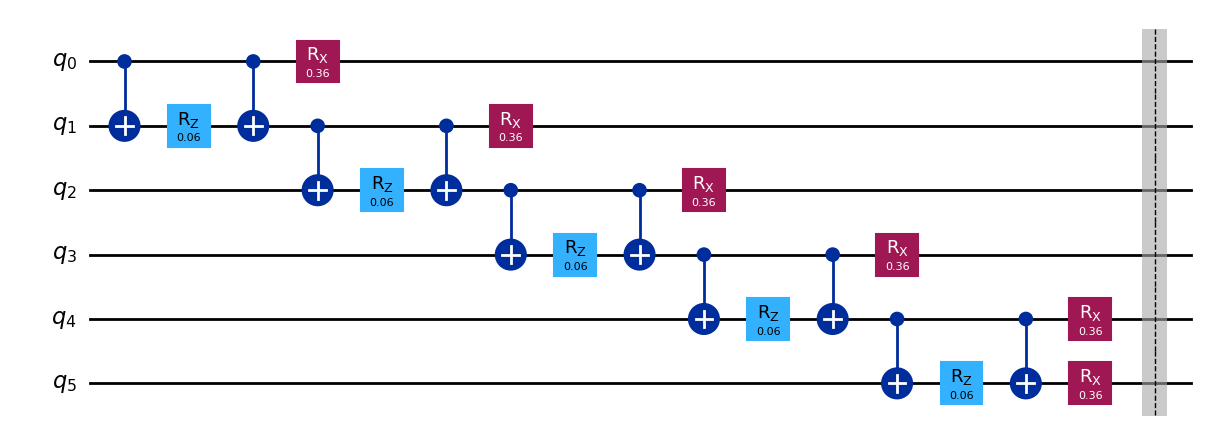


A'. TARGET IN HARDWARE BASIS
Same circuit expressed in ['rz', 'sx', 'x', 'cx']. Every Rx becomes Rz-SX-Rz, so all
continuous angles now live exclusively in Rz gates.
Gate counts: {'rz': 23, 'sx': 12, 'cx': 10, 'barrier': 1}


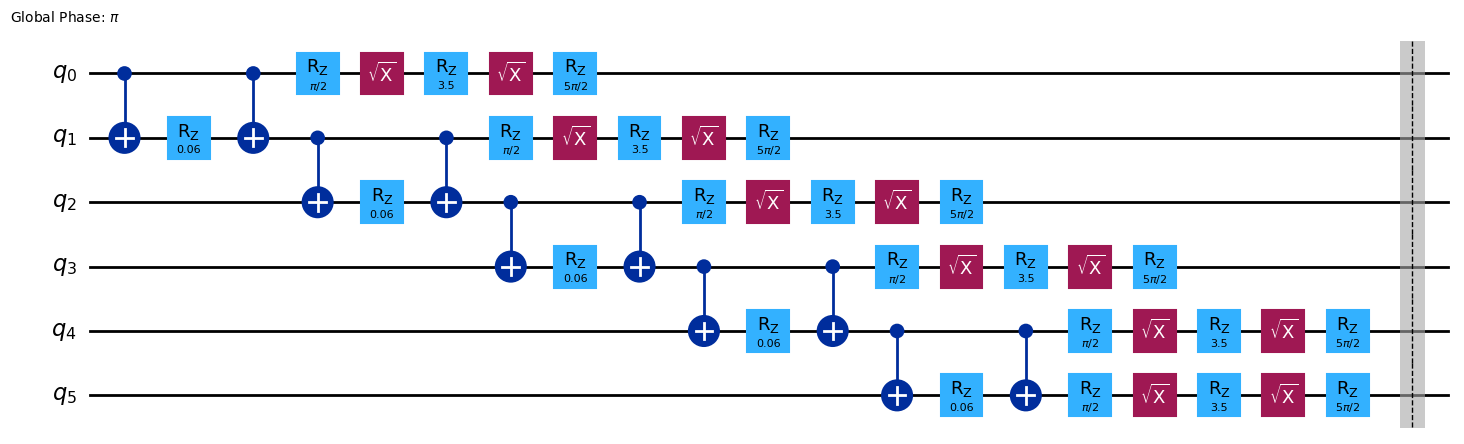


B. PROXY CIRCUIT (The Benchmark)
Identical CX structure and identical gate count. Each Rz(theta) is
snapped to Rz(k*pi/2), k in {0,1,2,3}, making the circuit a Clifford
circuit: efficiently simulatable with the same 'noise footprint'.
Gate counts: {'rz': 23, 'sx': 12, 'cx': 10, 'barrier': 1}
Is Clifford: True


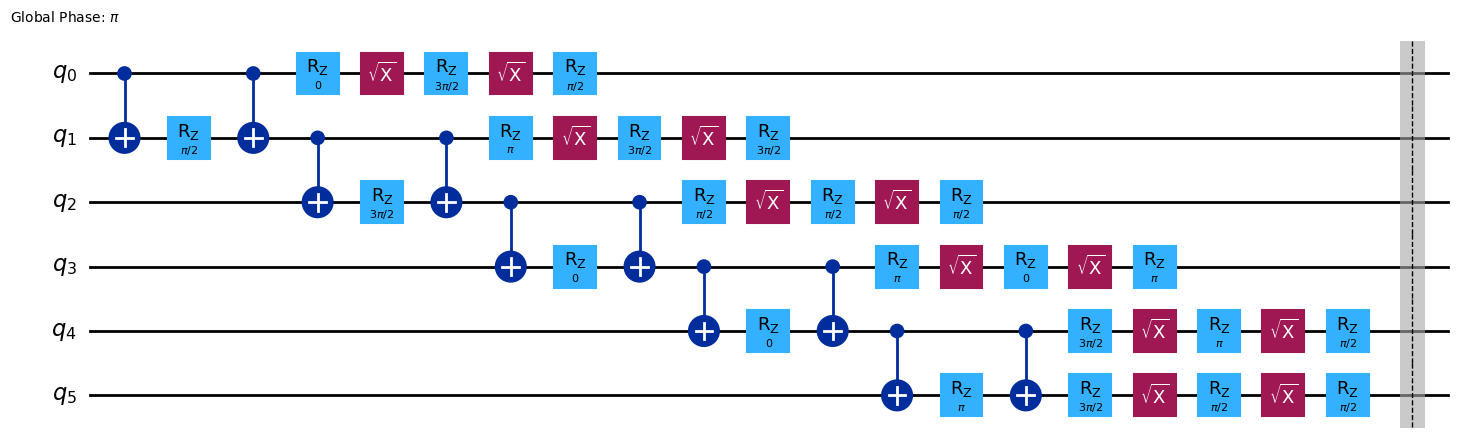


C. PAULI TWIRLED TARGET (Hardware Ready)
Every CX is sandwiched by random Paulis; the post-Paulis are chosen so
the logical circuit is unchanged. Averaging over twirls converts
coherent CX errors into stochastic Pauli noise (the PTA assumption).
Logically equivalent to target: True


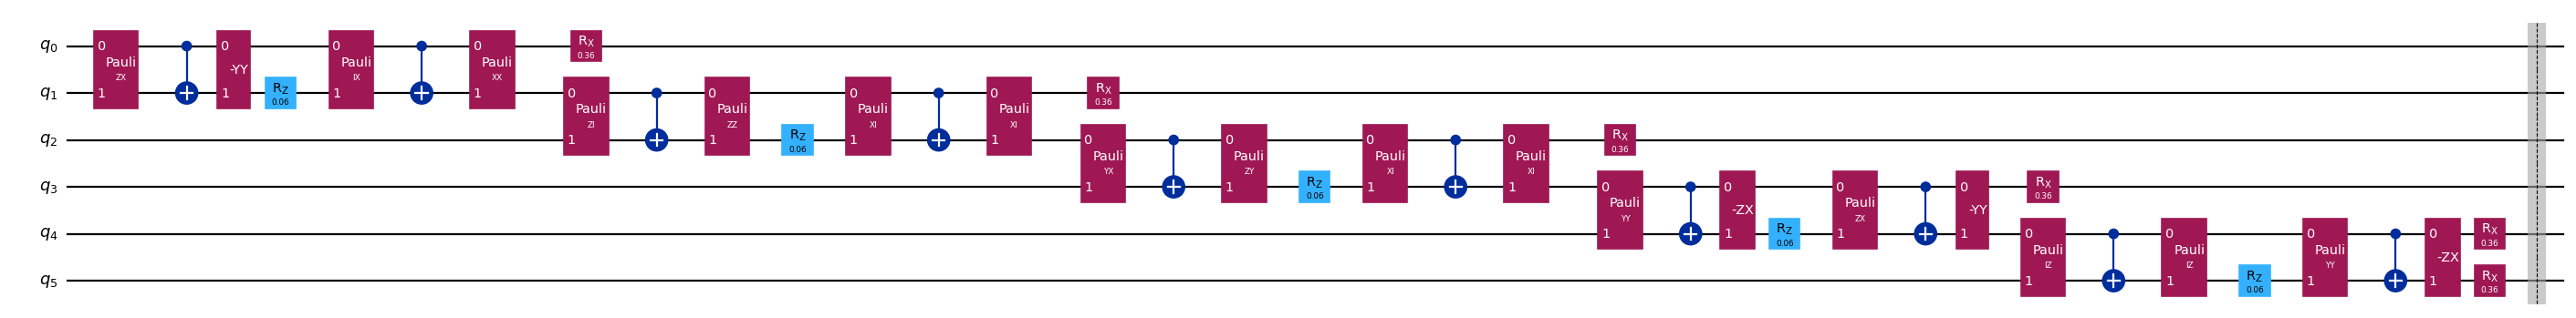

In [47]:
from qiskit.quantum_info import Operator

# =====================================================================
# Generation & Visualization
# =====================================================================
n_viz, J, h, dt = 6, 0.2, 1.2, 0.15


def section(title, *lines):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)
    for line in lines:
        print(line)


def show(qc, **kwargs):
    display(qc.draw("mpl", style="iqp", fold=-1, **kwargs))


# --- A. The Target (Ising) ---
target_circ = build_trotter_ising(n_viz, J, h, dt, trotter_steps=1)
section(
    "A. TARGET CIRCUIT (The Physics)",
    "One first-order Trotter step of the 1D transverse-field Ising model.",
    "Continuous-angle rotations (Rx, Rz) make it hard to simulate classically",
    "at scale and susceptible to coherent hardware errors.",
)
show(target_circ)

# --- A'. Target in hardware basis ---
target_basis = transpile(target_circ, basis_gates=BASIS, optimization_level=0)
section(
    "A'. TARGET IN HARDWARE BASIS",
    f"Same circuit expressed in {BASIS}. Every Rx becomes Rz-SX-Rz, so all",
    "continuous angles now live exclusively in Rz gates.",
    f"Gate counts: {dict(target_basis.count_ops())}",
)
show(target_basis)

# --- B. The Proxy (Cliffordized) ---
proxy_circ = cliffordize_circuit(target_basis, num_proxies=1)[0]
section(
    "B. PROXY CIRCUIT (The Benchmark)",
    "Identical CX structure and identical gate count. Each Rz(theta) is",
    "snapped to Rz(k*pi/2), k in {0,1,2,3}, making the circuit a Clifford",
    "circuit: efficiently simulatable with the same 'noise footprint'.",
    f"Gate counts: {dict(proxy_circ.count_ops())}",
    f"Is Clifford: {Clifford(proxy_circ) is not None}",
)
show(proxy_circ)

# --- C. The Twirled Target (Noisy Compilation) ---
twirled_circ = pauli_twirl(target_circ)
equiv = Operator(twirled_circ).equiv(Operator(target_circ))
section(
    "C. PAULI TWIRLED TARGET (Hardware Ready)",
    "Every CX is sandwiched by random Paulis; the post-Paulis are chosen so",
    "the logical circuit is unchanged. Averaging over twirls converts",
    "coherent CX errors into stochastic Pauli noise (the PTA assumption).",
    f"Logically equivalent to target: {equiv}",
)
show(twirled_circ, scale=0.8)

## 4. Comparison & Benchmarking Workflow
This script simulates the entire experiment. It compares the **Fidelity** of the actual Ising simulation against the **Average Fidelity** of the Clifford Proxies.

In [48]:
noise_model = NoiseModel(basis_gates=BASIS)
noise_model.add_all_qubit_quantum_error(depolarizing_error(1e-4, 1), ["rz", "sx", "x"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(1e-3, 2), ["cx"])

noisy_sim = AerSimulator(noise_model=noise_model, method="density_matrix")
ideal_sim = AerSimulator(method="statevector")

def fidelity_under_noise(qc):
    """Return F(ideal, noisy) for a basis-transpiled circuit."""
    ideal = qc.copy()
    ideal.save_statevector()
    sv = ideal_sim.run(ideal).result().get_statevector()

    noisy = qc.copy()
    noisy.save_density_matrix()
    rho = noisy_sim.run(noisy).result().data()["density_matrix"]
    return state_fidelity(sv, rho)

n_qubits, J, h, total_time = 8, 0.2, 1.2, 1.0
steps_list = range(1, 11)
results = []

for steps in steps_list:
    target = build_trotter_ising(n_qubits, J, h, total_time, steps)
    target_basis = transpile(target, basis_gates=BASIS, optimization_level=0)

    f_target = fidelity_under_noise(target_basis)
    f_proxies = [fidelity_under_noise(p) for p in cliffordize_circuit(target_basis, num_proxies=10)]
    results.append((steps, f_target, np.mean(f_proxies), np.std(f_proxies)))
    print(
        f"Depth {steps:02d} | Target: {f_target:.4f} | "
        f"Proxy: {np.mean(f_proxies):.4f} = {np.std(f_proxies):.4f}"
    )

Depth 01 | Target: 0.9872 | Proxy: 0.9872 = 0.0000
Depth 02 | Target: 0.9744 | Proxy: 0.9740 = 0.0004
Depth 03 | Target: 0.9618 | Proxy: 0.9609 = 0.0007
Depth 04 | Target: 0.9494 | Proxy: 0.9466 = 0.0016
Depth 05 | Target: 0.9372 | Proxy: 0.9334 = 0.0025
Depth 06 | Target: 0.9251 | Proxy: 0.9194 = 0.0029
Depth 07 | Target: 0.9132 | Proxy: 0.9059 = 0.0030
Depth 08 | Target: 0.9015 | Proxy: 0.8910 = 0.0035
Depth 09 | Target: 0.8899 | Proxy: 0.8776 = 0.0027
Depth 10 | Target: 0.8785 | Proxy: 0.8643 = 0.0031


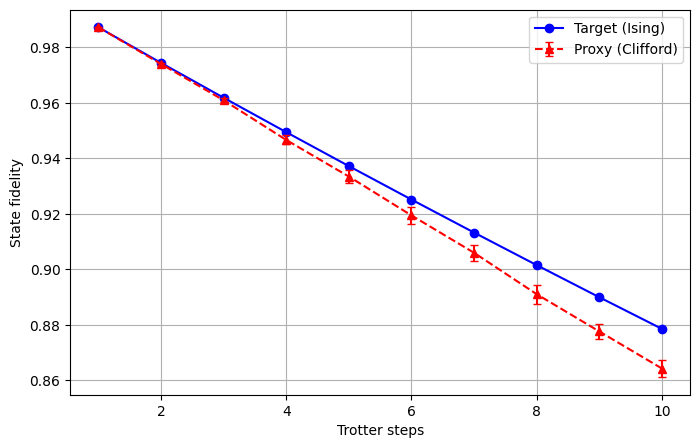

In [49]:
import matplotlib.pyplot as plt

steps, ft, fp, sp = map(np.array, zip(*results))
plt.figure(figsize=(8, 5))
plt.plot(steps, ft, "bo-", label="Target (Ising)")
plt.errorbar(steps, fp, yerr=sp, fmt="r^--", capsize=3, label="Proxy (Clifford)")
plt.xlabel("Trotter steps")
plt.ylabel("State fidelity")
plt.legend()
plt.grid(True)
plt.show()

## 5. Conclusion & Application From Benchmarking to Mitigation
Throughout this tutorial, we built a scalable framework to estimate the performance of a quantum algorithm. Let's summarize the core reasoning structure of what we accomplished:
* **The Physics Problem:** We started with a physical system (the 1D Transverse-Field Ising Model) and mapped its time evolution to a quantum circuit using Trotterization. This produced a non-Clifford circuit.
* **The Verification Bottleneck:** To achieve quantum advantage, we must run circuits too large to simulate classically. If we cannot simulate the target circuit, we cannot verify its fidelity directly.
* **The Proxy Solution:** We bypassed this bottleneck by generating Clifford Proxies. By replacing hard-to-simulate physics rotations with random 1-qubit Cliffords, we created benchmarking circuits that share the exact same entanglement structure (the CNOT footprint) as our application but remain classically tractable.
* **The Theoretical Guarantee:** Relying on the framework established by [Merkel et al.](https://arxiv.org/abs/2503.05943), we applied **Pauli twirling** to ensure all coherent errors were tailored into stochastic Pauli noise. Under this assumption, the efficiently calculable proxy fidelity accurately tracks the unknown target fidelity.

### Application: Estimating Observables (Error Mitigation)
Getting a fidelity estimate $F_{proxy}$ is not just an academic exercise; it is a mathematical tool to correct the final physics results.

In a real experiment, we are not measuring state vectors; we are measuring physical observables, such as the magnetization $\langle Z \rangle$ of the spin chain. The Clifford proxy's ideal output is exactly computable, so any deviation is attributable to noise; but the proxy carries no information about the physics observable itself.

If we measure a noisy magnetization value from the QPU, and the proxies give us the process fidelity, we can estimate the true, error-free magnetization using the depolarization model:
$$
    M_{mitigated} \approx \frac{M_{noisy}}{F_{proxy}}
$$
which is only correct if $F_{\text{proxy}}$ is the depolarizing parameter $\lambda$ of a global depolarizing channel, $\rho \to \lambda\rho + (1-\lambda)I/2^n$. State fidelity relates to it by $F = \lambda + (1-\lambda)/2^n$, so for small $n$ they differ. I'd phrase it as "the proxy estimates the effective depolarizing strength $\lambda$; traceless observables shrink by exactly $\lambda$, so $M_{\text{mitigated}} = M_{\text{noisy}}/\lambda$.

By dividing the raw expectation value by the proxy fidelity, we reverse the "shrinking" effect of the depolarizing noise channel.

### Future Directions
If we want to take this framework further, consider the following next steps:
* **Scale Up:** Increase the system size to 50+ qubits. At this scale, computing the target statevector will crash the machine, but the Clifford proxies (using Qiskit Aer's Clifford simulator method) will run in seconds.
* **Clifford Twirling:** Explore turning the Pauli noise into a fully symmetric global depolarizing channel using 2-qubit Clifford twirling, which can simplify the mitigation math even further.
* **Real Hardware:** Swap the `AerSimulator` for an IBM Quantum backend (`ibm_brisbane`, etc.) and test if the proxies accurately predict performance against real-world crosstalk and T1/T2 relaxation errors.

## 6. Scalable Benchmark of Trotterized Ising Models
This tutorial combines the modern Qiskit Utility-Scale workflow for quantum simulation with the Cliffordization benchmarking technique.
We will:
1. Define the Ising Hamiltonian using SparsePauliOp.
2. Generate time-evolution circuits using high-level synthesis (Lie-Trotter, Suzuki-Trotter $O(2)$, and Suzuki-Trotter $O(4)$).
3. Apply Clifford proxies to estimate the hardware fidelity of these drastically different circuit depths.

In [50]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp, state_fidelity
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

warnings.filterwarnings("ignore")

### 6.1. Defining the Hamiltonian & High-Level Synthesis
Instead of manually placing CX and Rz gates, we define the Hamiltonian mathematically. Qiskit's synthesis engines will automatically compile this into quantum gates.

In [51]:
BASIS = ["rz", "sx", "x", "cx"]
rng = np.random.default_rng(42)

# Hamiltonian
def get_hamiltonian(nqubits, J, h, alpha):
    ZZ = [("ZZ", [i, i + 1], -J) for i in range(nqubits - 1)]
    Z = [("Z", [i], -h * np.sin(alpha)) for i in range(nqubits)]
    X = [("X", [i], -h * np.cos(alpha)) for i in range(nqubits)]
    return SparsePauliOp.from_sparse_list(
        [*ZZ, *Z, *X], num_qubits=nqubits
    ).simplify()


n_qubits = 6
J, h, alpha = 0.2, 1.2, np.pi / 8
initial_state = "001100"
hamiltonian = get_hamiltonian(n_qubits, J, h, alpha)
print(f"Hamiltonian created with {len(hamiltonian)} Pauli terms.")

Hamiltonian created with 17 Pauli terms.


#### 6.2. Circuit Generation & Cliffordization
To Cliffordize these high-level circuits, we must first decompose them into base gates (`CX`, `Rx`, `Ry`, `Rz`). If we don't, the Cliffordizer won't be able to "see" the individual single-qubit rotations hidden inside the `PauliEvolutionGate`.

In [52]:
# Circuit construction
def build_evolution_circuit(hamiltonian, initial_state, total_time, steps,
                            formula):
    """Time-evolution circuit, transpiled to BASIS so every continuous
    angle lives in an rz gate."""
    n = hamiltonian.num_qubits
    qc = QuantumCircuit(n)
    # Basis-state preparation via X gates: Clifford, survives Cliffordization.
    # Qiskit is little-endian: bitstring[-1] is qubit 0.
    for q, bit in enumerate(reversed(initial_state)):
        if bit == "1":
            qc.x(q)
    qc.barrier()

    evo = PauliEvolutionGate(hamiltonian, total_time / steps, synthesis=formula)
    for _ in range(steps):
        qc.append(evo, range(n))

    return transpile(qc, basis_gates=BASIS, optimization_level=0)


def cliffordize_circuit(qc_basis, num_proxies=5, rng=rng):
    """Snap every rz(theta) to rz(k*pi/2). Gate count and depth unchanged."""
    proxies = []
    for _ in range(num_proxies):
        proxy = qc_basis.copy_empty_like()
        for instr in qc_basis.data:
            op = instr.operation
            if op.name == "rz":
                proxy.rz(rng.integers(4) * np.pi / 2, instr.qubits[0])
            else:
                proxy.append(op, instr.qubits, instr.clbits)
        proxies.append(proxy)
    return proxies

### 6.3. Benchmarking the Product Formulas
We will now benchmark `LieTrotter`, `SuzukiTrotter(order=2)`, and `SuzukiTrotter(order=4)`.

_Note: Higher-order formulas drastically increase the CNOT count. We expect their hardware fidelity to drop rapidly, which the Clifford proxies should accurately detect._

In [53]:
# Noise model & simulators
p_1q, p_2q = 1e-4, 1e-3
noise_model = NoiseModel(basis_gates=BASIS)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(p_1q, 1), ["rz", "sx", "x"]
)
noise_model.add_all_qubit_quantum_error(depolarizing_error(p_2q, 2), ["cx"])

noisy_sim = AerSimulator(noise_model=noise_model, method="density_matrix")
ideal_sim = AerSimulator(method="statevector")


def fidelity_under_noise(qc):
    ideal = qc.copy()
    ideal.save_statevector()
    sv = ideal_sim.run(ideal).result().get_statevector()

    noisy = qc.copy()
    noisy.save_density_matrix()
    rho = noisy_sim.run(noisy).result().data()["density_matrix"]
    return state_fidelity(sv, rho)


# Benchmark
total_time = 1.0
steps_list = [1, 2, 3, 4, 6, 8, 10]
num_proxies = 5

formulas = {
    "Lie-Trotter": LieTrotter(),
    "Suzuki-Trotter (O2)": SuzukiTrotter(order=2),
    "Suzuki-Trotter (O4)": SuzukiTrotter(order=4),
}

results = {}
print("Starting Benchmarks...\n" + "=" * 72)

for name, formula in formulas.items():
    print(f"\n{name}\n" + "-" * 72)
    rows = []

    for steps in steps_list:
        target = build_evolution_circuit(
            hamiltonian, initial_state, total_time, steps, formula
        )
        ops = target.count_ops()
        n_1q = sum(ops.get(g, 0) for g in ["rz", "sx", "x"])
        n_cx = ops.get("cx", 0)

        f_target = fidelity_under_noise(target)
        f_proxies = [
            fidelity_under_noise(p)
            for p in cliffordize_circuit(target, num_proxies)
        ]
        f_mean, f_std = np.mean(f_proxies), np.std(f_proxies)
        rows.append((steps, f_target, f_mean, f_std, n_1q, n_cx))

        print(
            f"Steps {steps:02d} | Target {f_target:.4f} | "
            f"Proxy {f_mean:.4f} ± {f_std:.4f} | "
            f"1Q {n_1q:5d} | CX {n_cx:5d}"
        )

    results[name] = np.array(rows)

print("\n" + "=" * 72 + "\nBenchmark Complete!")

Starting Benchmarks...

Lie-Trotter
------------------------------------------------------------------------
Steps 01 | Target 0.9904 | Proxy 0.9904 ± 0.0000 | 1Q    43 | CX    10
Steps 02 | Target 0.9808 | Proxy 0.9807 ± 0.0003 | 1Q    84 | CX    20
Steps 03 | Target 0.9714 | Proxy 0.9703 ± 0.0010 | 1Q   125 | CX    30
Steps 04 | Target 0.9621 | Proxy 0.9610 ± 0.0008 | 1Q   166 | CX    40
Steps 06 | Target 0.9438 | Proxy 0.9395 ± 0.0023 | 1Q   248 | CX    60
Steps 08 | Target 0.9259 | Proxy 0.9161 ± 0.0013 | 1Q   330 | CX    80
Steps 10 | Target 0.9083 | Proxy 0.8980 ± 0.0028 | 1Q   412 | CX   100

Suzuki-Trotter (O2)
------------------------------------------------------------------------
Steps 01 | Target 0.9812 | Proxy 0.9809 ± 0.0003 | 1Q    79 | CX    20
Steps 02 | Target 0.9625 | Proxy 0.9621 ± 0.0007 | 1Q   156 | CX    40
Steps 03 | Target 0.9444 | Proxy 0.9430 ± 0.0013 | 1Q   233 | CX    60
Steps 04 | Target 0.9267 | Proxy 0.9219 ± 0.0022 | 1Q   310 | CX    80
Steps 06 | Targe

### 6.4. Plotting State Fidelity for All Trotter Orders  
The plot below illustrates the brutal trade-off in quantum simulation: while `Suzuki-Trotter (O4)` has the lowest mathematical error, its massive circuit depth causes the hardware fidelity to collapse almost instantly.

Crucially, notice how the dashed proxy lines accurately track their respective solid target lines for every formula.

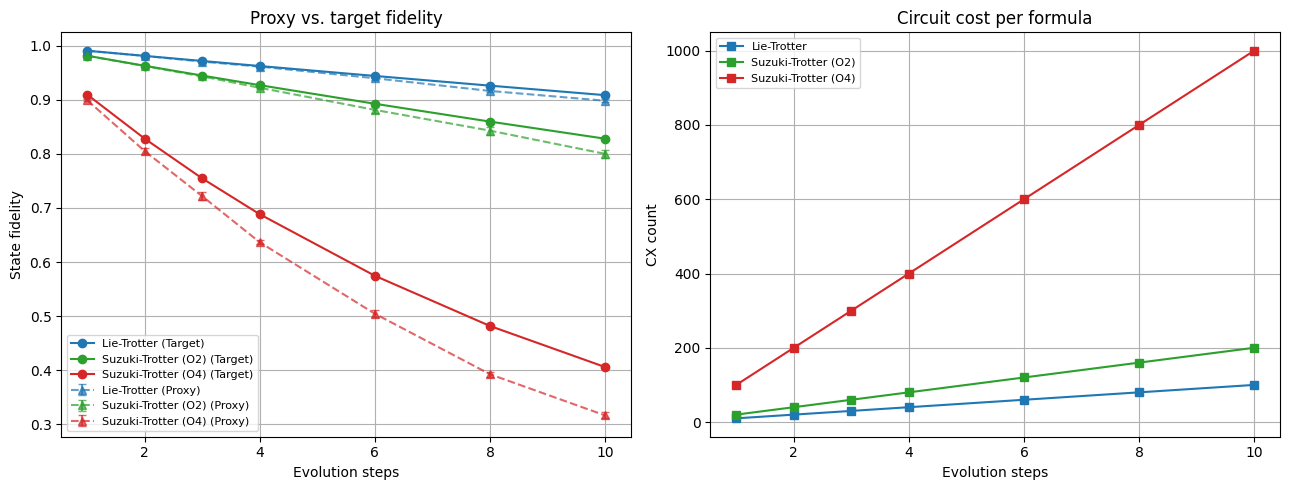

In [54]:
# Plot
fig, (ax_fid, ax_cx) = plt.subplots(1, 2, figsize=(13, 5))

for (name, r), color in zip(results.items(), ["C0", "C2", "C3"]):
    steps, ft, fp, sp, _, ncx = r.T
    ax_fid.plot(steps, ft, "o-", color=color, label=f"{name} (Target)")
    ax_fid.errorbar(
        steps, fp, yerr=sp, fmt="^--", color=color, alpha=0.7, capsize=3,
        label=f"{name} (Proxy)",
    )
    ax_cx.plot(steps, ncx, "s-", color=color, label=name)

ax_fid.set(xlabel="Evolution steps", ylabel="State fidelity",
           title="Proxy vs. target fidelity")
ax_fid.grid(True)
ax_fid.legend(fontsize=8)

ax_cx.set(xlabel="Evolution steps", ylabel="CX count",
          title="Circuit cost per formula")
ax_cx.grid(True)
ax_cx.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 6.5 Repeating Process for $5, 10 ,15$ Qubits

**NOTE**: Going to 15 qubits breaks the density‑matrix approach (a 15‑qubit density matrix is $4^{15}$ complex entries ≈ 16 GB), so the noisy fidelity must be estimated differently. The cleanest option is Monte‑Carlo noise trajectories: Aer's statevector method samples one Pauli error realization per shot, and the fidelity is $F \approx \frac{1}{N}\sum_k |\langle\psi_{\text{ideal}}|\psi_k\rangle|^2$. That's exact in expectation and scales to ~20 qubits. For 25 qubits even a single statevector is 512 MB and the target becomes unsimulable — which is precisely the regime where you'd drop the target and trust the proxy alone, so I'd go with 5, 10, 15.


5 qubits | initial state 01100

Lie-Trotter
------------------------------------------------------------------------
Steps 01 | Target 1.0000 | Proxy 0.9880 ± 0.0160 | CX     8
Steps 02 | Target 0.9769 | Proxy 0.9800 ± 0.0219 | CX    16
Steps 03 | Target 0.9642 | Proxy 0.9720 ± 0.0160 | CX    24
Steps 04 | Target 0.9651 | Proxy 0.9720 ± 0.0299 | CX    32
Steps 06 | Target 0.9656 | Proxy 0.9520 ± 0.0271 | CX    48
Steps 08 | Target 0.9365 | Proxy 0.9360 ± 0.0265 | CX    64
Steps 10 | Target 0.9438 | Proxy 0.9360 ± 0.0233 | CX    80

Suzuki-Trotter (O2)
------------------------------------------------------------------------
Steps 01 | Target 0.9783 | Proxy 0.9720 ± 0.0240 | CX    16
Steps 02 | Target 0.9588 | Proxy 0.9600 ± 0.0000 | CX    32
Steps 03 | Target 0.9262 | Proxy 0.9560 ± 0.0196 | CX    48
Steps 04 | Target 0.9152 | Proxy 0.9400 ± 0.0126 | CX    64
Steps 06 | Target 0.9024 | Proxy 0.9360 ± 0.0367 | CX    96
Steps 08 | Target 0.8887 | Proxy 0.8960 ± 0.0265 | CX   128
Steps 10

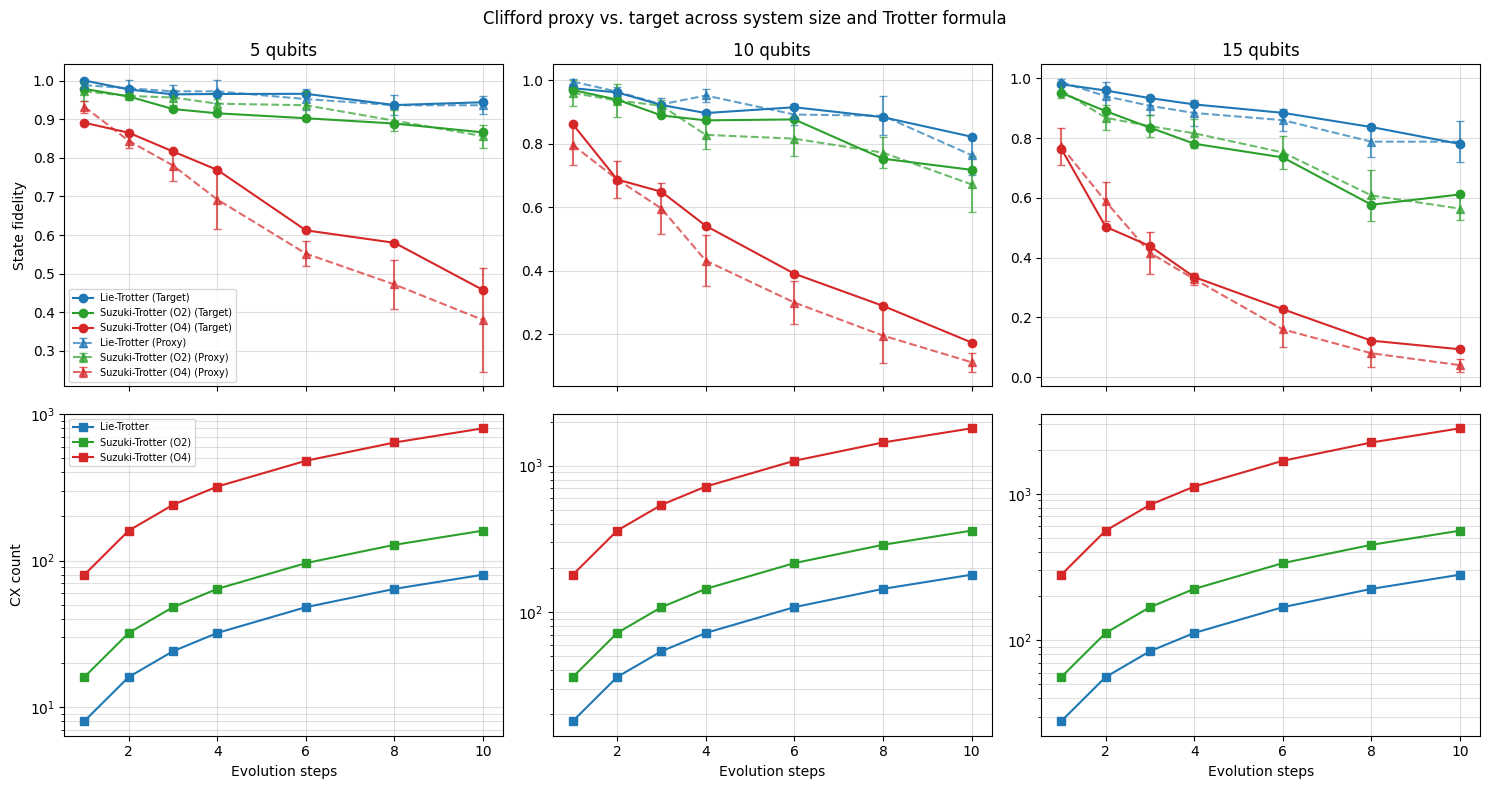

In [58]:
# ============================================================
# Trajectory-based fidelity (scales beyond density-matrix limit)
# ============================================================
noisy_sim = AerSimulator(noise_model=noise_model, method="statevector")
ideal_sim = AerSimulator(method="statevector")


def fidelity_under_noise(qc, shots=200):
    """F ~ mean_k |<psi_ideal | psi_k>|^2 over noise trajectories."""
    ideal = qc.copy()
    ideal.save_statevector()
    psi = np.asarray(ideal_sim.run(ideal).result().get_statevector())

    noisy = qc.copy()
    noisy.save_statevector(pershot=True)
    trajs = noisy_sim.run(noisy, shots=shots).result().data()["statevector"]
    return np.mean([abs(np.vdot(psi, np.asarray(t))) ** 2 for t in trajs])


def centered_excitation(n, width=2):
    """Basis state with `width` ones in the middle, e.g. '001100' for n=6."""
    bits = ["0"] * n
    start = (n - width) // 2
    for i in range(start, start + width):
        bits[i] = "1"
    return "".join(bits)


# ============================================================
# Benchmark for one system size
# ============================================================
def run_benchmark(n_qubits, formulas, steps_list, total_time=1.0,
                  num_proxies=5, target_shots=200, proxy_shots=50):
    hamiltonian = get_hamiltonian(n_qubits, J, h, alpha)
    init = centered_excitation(n_qubits)
    results = {}

    print(f"\n{'=' * 72}\n{n_qubits} qubits | initial state {init}\n{'=' * 72}")
    for name, formula in formulas.items():
        print(f"\n{name}\n" + "-" * 72)
        rows = []
        for steps in steps_list:
            target = build_evolution_circuit(
                hamiltonian, init, total_time, steps, formula
            )
            ops = target.count_ops()
            n_cx = ops.get("cx", 0)

            f_target = fidelity_under_noise(target, target_shots)
            f_proxies = [
                fidelity_under_noise(p, proxy_shots)
                for p in cliffordize_circuit(target, num_proxies)
            ]
            f_mean, f_std = np.mean(f_proxies), np.std(f_proxies)
            rows.append((steps, f_target, f_mean, f_std, n_cx))
            print(
                f"Steps {steps:02d} | Target {f_target:.4f} | "
                f"Proxy {f_mean:.4f} ± {f_std:.4f} | CX {n_cx:5d}"
            )
        results[name] = np.array(rows)
    return results


# ============================================================
# Run across system sizes
# ============================================================
qubit_sizes = [5, 10, 15]
steps_list = [1, 2, 3, 4, 6, 8, 10]
formulas = {
    "Lie-Trotter": LieTrotter(),
    "Suzuki-Trotter (O2)": SuzukiTrotter(order=2),
    "Suzuki-Trotter (O4)": SuzukiTrotter(order=4),
}

all_results = {n: run_benchmark(n, formulas, steps_list) for n in qubit_sizes}


# ============================================================
# Plot: rows = (fidelity, CX count), columns = system size
# ============================================================
fig, axes = plt.subplots(
    2, len(qubit_sizes), figsize=(5 * len(qubit_sizes), 8), sharex=True
)
colors = ["C0", "C2", "C3"]

for col, n in enumerate(qubit_sizes):
    ax_fid, ax_cx = axes[0, col], axes[1, col]
    for (name, r), c in zip(all_results[n].items(), colors):
        steps, ft, fp, sp, ncx = r.T
        ax_fid.plot(steps, ft, "o-", color=c, label=f"{name} (Target)")
        ax_fid.errorbar(
            steps, fp, yerr=sp, fmt="^--", color=c, alpha=0.7, capsize=3,
            label=f"{name} (Proxy)",
        )
        ax_cx.plot(steps, ncx, "s-", color=c, label=name)

    ax_fid.set(title=f"{n} qubits", ylabel="State fidelity" if col == 0 else "")
    ax_cx.set(xlabel="Evolution steps", ylabel="CX count" if col == 0 else "")
    ax_cx.set_yscale("log")
    for ax in (ax_fid, ax_cx):
        ax.grid(True, which="both", alpha=0.4)

axes[0, 0].legend(fontsize=7)
axes[1, 0].legend(fontsize=7)
fig.suptitle("Clifford proxy vs. target across system size and Trotter formula")
plt.tight_layout()
plt.show()

### Notes

- **Runtime**. The 15‑qubit ST(4) circuits at 10 steps have several thousand CX gates; 200 trajectories × 6 step values × 3 formulas + proxies will take minutes, not seconds. If it's too slow, reduce target_shots/proxy_shots or drop 10 from steps_list — the fidelity standard error scales as $1/\sqrt{N_{\text{shots}}}$, so 100 shots is still ~±0.01.

- **Memory**. pershot=True stores all trajectories: at 15 qubits that's 200 × 512 KB ≈ 100 MB, fine. Don't push this past ~20 qubits.

- **Log scale on CX count** matters here, because CX cost spans ~2 orders of magnitude between Lie‑Trotter at 1 step and ST(4) at 10 steps.

- **What to expect**. Fidelities at 15 qubits will collapse toward zero for ST(4) at large step counts (thousands of CX × $10^{-3}$). That's the tutorial's punchline: the proxy predicts this collapse without needing the target simulation.

## 7. Cross-Entropy Benchmarking (XEB)

Linear XEB, $F_{\text{XEB}} = 2^n\,\mathbb{E}_{x\sim q}[p_{\text{ideal}}(x)] - 1$, equals $\lambda$ only for Haar‑random circuits where $2^n\sum_x p^2 \approx 2$. Neither of your circuits is Haar‑random:


- Clifford proxies: $p_{\text{ideal}}(x)$ is $2^{-k}$ on a stabilizer support of size $2^k$ and zero elsewhere.

- Trotter target: shallow, weakly entangled, far from Porter‑Thomas.

Under global depolarizing noise $q = \lambda p + (1-\lambda)/2^n$, you get $\mathbb{E}_q[p] = \lambda\sum p^2 + (1-\lambda)/2^n$, so the fix is to normalize:
$$
\lambda_{\text{XEB}} = \frac{2^n\,\mathbb{E}_{x\sim q}[p_{\text{ideal}}(x)] - 1}{2^n\sum_x p_{\text{ideal}}(x)^2 - 1}
$$
This is unbiased for any ideal distribution, as long as the denominator is nonzero.

If a random Cliffordization happens to produce a stabilizer state with full support (\(k = n\)), the ideal distribution is uniform and XEB carries zero information (denominator = 0).

In [56]:
from qiskit.quantum_info import Statevector


def xeb_lambda(qc, shots=4000):
    """Normalized linear XEB estimate of the depolarizing parameter lambda.
    Returns nan if the ideal output distribution is uniform."""
    dim = 2**qc.num_qubits
    p_ideal = Statevector(qc).probabilities()  # replace with stabilizer sim
    purity = np.sum(p_ideal**2)                #   for proxies at large n
    denom = dim * purity - 1
    if denom < 1e-9:
        return np.nan

    meas = qc.copy()
    meas.measure_all()
    counts = noisy_sim.run(meas, shots=shots).result().get_counts()
    mean_p = sum(
        p_ideal[int(b.replace(" ", ""), 2)] * c for b, c in counts.items()
    ) / shots
    return (dim * mean_p - 1) / denom


def lambda_from_state_fidelity(F, n):
    """Invert F = lambda + (1 - lambda) / 2^n."""
    return (F - 2.0**-n) / (1 - 2.0**-n)


# --- Compare XEB lambda vs. fidelity-derived lambda for one size ---
n_qubits = 10
hamiltonian = get_hamiltonian(n_qubits, J, h, alpha)
init = centered_excitation(n_qubits)
formula = SuzukiTrotter(order=2)

print(f"{'steps':>5} | {'lam_F target':>12} | {'lam_XEB target':>14} | "
      f"{'lam_XEB proxy':>13} | {'valid proxies':>13}")
print("-" * 72)
for steps in [1, 2, 4, 6, 8, 10]:
    target = build_evolution_circuit(hamiltonian, init, 1.0, steps, formula)

    lam_F = lambda_from_state_fidelity(
        fidelity_under_noise(target, shots=200), n_qubits
    )
    lam_xeb_t = xeb_lambda(target)

    proxy_lams = [xeb_lambda(p) for p in cliffordize_circuit(target, 8)]
    proxy_lams = [x for x in proxy_lams if not np.isnan(x)]

    print(f"{steps:>5} | {lam_F:12.4f} | {lam_xeb_t:14.4f} | "
          f"{np.mean(proxy_lams):13.4f} | {len(proxy_lams):>13}")

steps | lam_F target | lam_XEB target | lam_XEB proxy | valid proxies
------------------------------------------------------------------------
    1 |       0.9657 |         0.9968 |        0.9839 |             8
    2 |       0.9494 |         0.9465 |        0.9741 |             8
    4 |       0.8683 |         0.9281 |        0.9330 |             8
    6 |       0.7874 |         0.9178 |        0.8768 |             8
    8 |       0.7311 |         0.9120 |        0.8412 |             7
   10 |       0.6718 |         0.8557 |        0.7653 |             8


### What to look for

- lam_F vs. lam_XEB target should agree to within shot noise (~0.01 at 4000 shots). Disagreement means the noise isn't well approximated by a global depolarizing channel — at which point the $M/\lambda$ mitigation formula is also unreliable. That's a useful diagnostic to show in the tutorial.

- Proxy XEB should track target XEB about as well as proxy state fidelity tracked target fidelity earlier.

- Valid proxy count tells you how often you hit uniform‑support Cliffords. With your rz(kπ/2) snapping it's rare but nonzero; if it becomes a problem, reject and resample.

### Caveats worth a sentence in the text

- XEB is only a fidelity proxy under stochastic Pauli noise; coherent errors can inflate it (Gao et al., 2021). This is another reason Pauli twirling belongs in the pipeline, not just a formality.

- Shot cost: $\text{Var}(\lambda_{\text{XEB}}) \sim 1/(N_{\text{shots}} \cdot \text{denom})$. For near‑product target states the denominator is small (few bitstrings carry weight), so you need more shots than for a random circuit. Clifford proxies with $k \ll n$ are actually easier here.

- For 15+ qubits, replace Statevector(qc).probabilities() for the proxies with StabilizerState(qc) and check support membership per sampled bitstring; the target side still needs a statevector, which is again exactly the scaling wall the proxy method is designed to bypass.

## 8. Real Hardware Simulation

Running everything on a realistic device model (FakeBrisbane → AerSimulator.from_backend) with a few things change compared to ideal-noise section:

* **Basis is ecr, not cx on Brisbane.** Cliffordization is unaffected (all continuous angles still live in rz; ecr/sx/x are Clifford). Count ecr instead of cx.

* **Layout matters.** The Hamiltonian is a nearest-neighbour chain, so map it onto a linear path of physical qubits to avoid routing SWAPs (which would otherwise differ per step count and muddy the comparison).

* **127-qubit circuits.** Aer truncates idle qubits automatically, so statevector trajectories still work. For fidelity, ideal and noisy runs use the same transpiled circuit, so the truncated qubit orderings match. For XEB, measure only the active qubits and get ideal probabilities via save_probabilities(qubits=...) with the same qubit list.

Backend basis: ['id', 'x', 'measure', 'if_else', 'rz', 'reset', 'ecr', 'sx', 'delay', 'switch_case', 'for_loop']

8 qubits | init 00011000 | physical chain [0, 1, 2, 3, 4, 5, 6, 7]

Lie-Trotter
------------------------------------------------------------------------------
Steps 01 | F_t 0.8305 | F_p 0.8140 ± 0.0064 | lam_F 0.830 | lam_XEB(t) 0.657 | lam_XEB(p) 0.778 | ECR   14
Steps 02 | F_t 0.6841 | F_p 0.6565 ± 0.0051 | lam_F 0.683 | lam_XEB(t) 0.695 | lam_XEB(p) 0.599 | ECR   28
Steps 04 | F_t 0.4764 | F_p 0.4350 ± 0.0129 | lam_F 0.474 | lam_XEB(t) 0.558 | lam_XEB(p) 0.553 | ECR   56
Steps 06 | F_t 0.3381 | F_p 0.2804 ± 0.0131 | lam_F 0.336 | lam_XEB(t) 0.557 | lam_XEB(p) 0.463 | ECR   84
Steps 08 | F_t 0.2444 | F_p 0.1736 ± 0.0130 | lam_F 0.241 | lam_XEB(t) 0.344 | lam_XEB(p) 0.173 | ECR  112
Steps 10 | F_t 0.1801 | F_p 0.1123 ± 0.0130 | lam_F 0.177 | lam_XEB(t) 0.267 | lam_XEB(p) 0.140 | ECR  140

Suzuki-Trotter (O2)
----------------------------------------------------------------

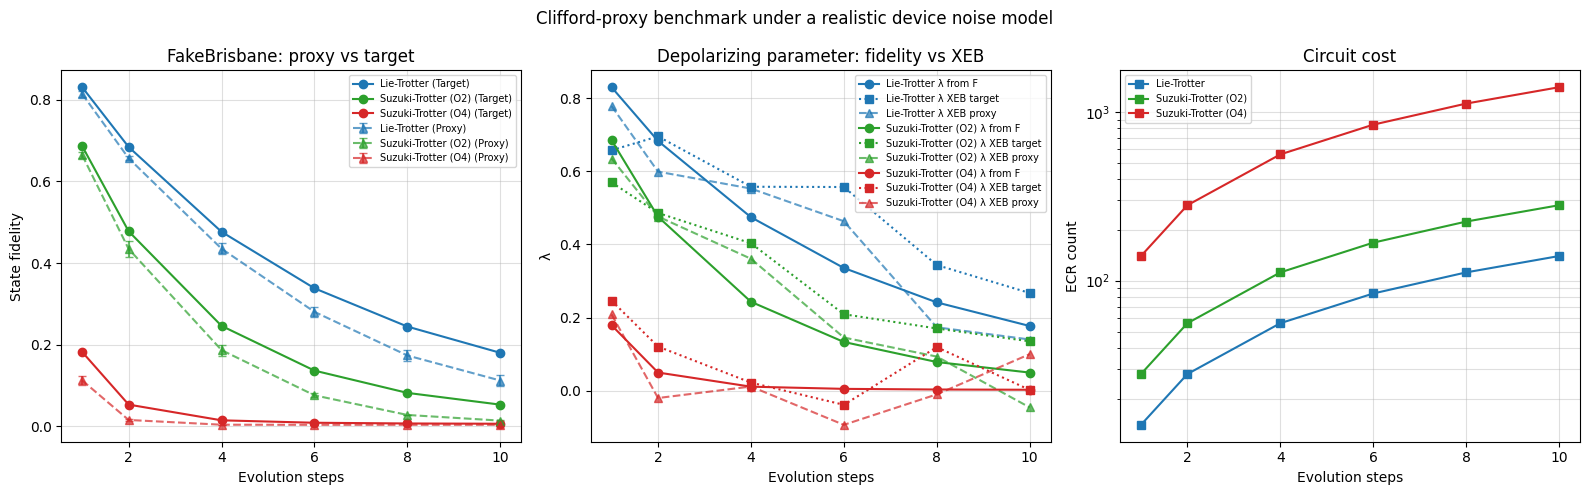

In [57]:
# ============================================================
# Hardware-realistic benchmark: FakeBrisbane noise model
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

backend = FakeBrisbane()
print("Backend basis:", backend.operation_names)


# ---------- 1. Pick a linear chain of physical qubits ----------
def find_linear_chain(coupling_map, n):
    """DFS for a simple path of n physical qubits (no routing SWAPs needed)."""
    adj = {}
    for a, b in coupling_map.get_edges():
        adj.setdefault(a, set()).add(b)
        adj.setdefault(b, set()).add(a)

    def dfs(path):
        if len(path) == n:
            return path
        for nxt in sorted(adj[path[-1]]):
            if nxt not in path:
                res = dfs(path + [nxt])
                if res:
                    return res
        return None

    for start in sorted(adj):
        res = dfs([start])
        if res:
            return res
    raise ValueError(f"No chain of length {n} found")


# ---------- 2. Circuit construction against the backend ----------
def build_hw_circuit(hamiltonian, initial_state, total_time, steps,
                     formula, layout, opt_level=1):
    n = hamiltonian.num_qubits
    qc = QuantumCircuit(n)
    for q, bit in enumerate(reversed(initial_state)):
        if bit == "1":
            qc.x(q)
    evo = PauliEvolutionGate(hamiltonian, total_time / steps, synthesis=formula)
    for _ in range(steps):
        qc.append(evo, range(n))

    pm = generate_preset_pass_manager(
        optimization_level=opt_level, backend=backend, initial_layout=layout
    )
    return pm.run(qc)


def active_qubits(qc):
    """Physical qubit indices that carry at least one gate."""
    used = set()
    for instr in qc.data:
        for q in instr.qubits:
            used.add(qc.find_bit(q).index)
    return sorted(used)


def get_cropped_simulators(layout):
    """Creates an AerSimulator truncated ONLY to active qubits to save RAM."""
    full_noise_model = NoiseModel.from_backend(backend)
    
    # Ideal statevector simulator for n qubits
    ideal_sim = AerSimulator(method="statevector")
    
    # Density-matrix / Statevector noisy simulator for trimmed qubits
    noisy_sim = AerSimulator(
        method="density_matrix",
        noise_model=full_noise_model
    )
    return ideal_sim, noisy_sim

def extract_active_subcircuit(qc):
    """Trims a 127-qubit transpiled circuit down to only active physical qubits."""
    qubits = active_qubits(qc)
    q_map = {q: i for i, q in enumerate(qubits)}
    
    # Create an n-qubit circuit with only active qubits
    sub_qc = QuantumCircuit(len(qubits))
    for instr in qc.data:
        if instr.operation.name not in ["barrier", "measure", "save_statevector", "save_probabilities"]:
            new_q = [q_map[qc.find_bit(q).index] for q in instr.qubits]
            sub_qc.append(instr.operation, new_q)
    return sub_qc, qubits


# ---------- 3. Metrics ----------
def hw_fidelity_density(qc, ideal_sim, noisy_sim):
    """Exact fidelity <psi_ideal| rho_noisy |psi_ideal> without 127-qubit memory overhead."""
    # 1. Truncate ideal circuit to only active qubits
    ideal, qubits = extract_active_subcircuit(qc)
    ideal.save_statevector()
    psi = ideal_sim.run(ideal).result().get_statevector().data
    
    # 2. Compute noisy density matrix (using active qubits)
    noisy = qc.copy()
    noisy.save_density_matrix(qubits=qubits)
    rho = noisy_sim.run(noisy).result().data()["density_matrix"].data
    
    # 3. Fidelity = <psi|rho|psi>
    fidelity = np.real(np.vdot(psi, rho @ psi))
    return float(np.clip(fidelity, 0.0, 1.0))


def hw_xeb_lambda(qc, ideal_sim, noisy_sim, shots=4000):
    """Linear XEB computed on active physical qubits."""
    # 1. Compute probabilities on trimmed ideal circuit
    ideal, qubits = extract_active_subcircuit(qc)
    n = len(qubits)
    dim = 2**n

    ideal.save_probabilities()
    p_ideal = ideal_sim.run(ideal).result().data()["probabilities"]
    
    denom = dim * np.sum(p_ideal**2) - 1
    if denom < 1e-9:
        return np.nan

    # 2. Run measurement on noisy simulator for active qubits
    meas = qc.copy()
    meas.add_register(ClassicalRegister(n, "m"))
    meas.measure(qubits, range(n))
    counts = noisy_sim.run(meas, shots=shots).result().get_counts()
    
    mean_p = sum(p_ideal[int(b.replace(" ", ""), 2)] * c for b, c in counts.items()) / shots
    return float((dim * mean_p - 1) / denom)


# ---------- 4. Benchmark loop ----------
def run_hw_benchmark(n_qubits, formulas, steps_list, total_time=1.0,
                     num_proxies=5, target_shots=200, proxy_shots=50):
    hamiltonian = get_hamiltonian(n_qubits, J, h, alpha)
    init = centered_excitation(n_qubits)
    layout = find_linear_chain(backend.coupling_map, n_qubits)
    
    # Initialize light simulators for this run
    ideal_sim, noisy_sim = get_cropped_simulators(layout)
    
    results = {}

    print(f"\n{'=' * 78}\n{n_qubits} qubits | init {init} | "
          f"physical chain {layout}\n{'=' * 78}")
    for name, formula in formulas.items():
        print(f"\n{name}\n" + "-" * 78)
        rows = []
        for steps in steps_list:
            target = build_hw_circuit(
                hamiltonian, init, total_time, steps, formula, layout
            )
            n_ecr = target.count_ops().get("ecr", 0)

            f_t = hw_fidelity_density(target, ideal_sim, noisy_sim)
            lam_F = lambda_from_state_fidelity(f_t, n_qubits)
            lam_xeb_t = hw_xeb_lambda(target, ideal_sim, noisy_sim, shots=target_shots)

            proxies = cliffordize_circuit(target, num_proxies)
            f_p = [hw_fidelity_density(p, ideal_sim, noisy_sim) for p in proxies]
            lam_xeb_p = [x for x in [hw_xeb_lambda(p, ideal_sim, noisy_sim, shots=proxy_shots) for p in proxies]
                         if not np.isnan(x)]

            rows.append((steps, f_t, np.mean(f_p), np.std(f_p),
                         lam_F, lam_xeb_t,
                         np.mean(lam_xeb_p) if lam_xeb_p else np.nan, n_ecr))
            print(
                f"Steps {steps:02d} | F_t {f_t:.4f} | "
                f"F_p {np.mean(f_p):.4f} ± {np.std(f_p):.4f} | "
                f"lam_F {lam_F:.3f} | lam_XEB(t) {lam_xeb_t:.3f} | "
                f"lam_XEB(p) {rows[-1][6]:.3f} | ECR {n_ecr:4d}"
            )
        results[name] = np.array(rows)
    return results


formulas = {
    "Lie-Trotter": LieTrotter(),
    "Suzuki-Trotter (O2)": SuzukiTrotter(order=2),
    "Suzuki-Trotter (O4)": SuzukiTrotter(order=4),
}
steps_list = [1, 2, 4, 6, 8, 10]
hw_results = run_hw_benchmark(8, formulas, steps_list)


# ---------- 5. Plot ----------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ax_f, ax_l, ax_c = axes
for (name, r), c in zip(hw_results.items(), ["C0", "C2", "C3"]):
    st, ft, fp, sp, lF, lXt, lXp, necr = r.T
    ax_f.plot(st, ft, "o-", color=c, label=f"{name} (Target)")
    ax_f.errorbar(st, fp, yerr=sp, fmt="^--", color=c, alpha=0.7,
                  capsize=3, label=f"{name} (Proxy)")
    ax_l.plot(st, lF, "o-", color=c, label=f"{name} λ from F")
    ax_l.plot(st, lXt, "s:", color=c, label=f"{name} λ XEB target")
    ax_l.plot(st, lXp, "^--", color=c, alpha=0.7, label=f"{name} λ XEB proxy")
    ax_c.plot(st, necr, "s-", color=c, label=name)

ax_f.set(xlabel="Evolution steps", ylabel="State fidelity",
         title="FakeBrisbane: proxy vs target")
ax_l.set(xlabel="Evolution steps", ylabel="λ",
         title="Depolarizing parameter: fidelity vs XEB")
ax_c.set(xlabel="Evolution steps", ylabel="ECR count", yscale="log",
         title="Circuit cost")
for ax in axes:
    ax.grid(True, which="both", alpha=0.4)
    ax.legend(fontsize=7)
fig.suptitle("Clifford-proxy benchmark under a realistic device noise model")
plt.tight_layout()
plt.show()

### Notes and expectations:

- **Install:** pip install qiskit-ibm-runtime for FakeBrisbane. If you'd rather stay pure Aer, AerSimulator.from_backend also accepts any BackendV2 with a target.

- **Fidelity vs XEB gap:** hw_xeb_lambda includes readout error (Brisbane ~1–3% per qubit), while hw_fidelity does not, so expect $λ_{XEB}$ to sit noticeably below $λ_F$. If you want to isolate gate noise, pass `AerSimulator.from_backend(backend)` with the readout errors stripped (`NoiseModel.from_backend(backend, readout_error=False)`) and build the simulator from that noise model.

- **Proxy XEB validity:** Clifford circuits often produce flat output distributions (denominator → 0, returns nan), which is why the code filters them. It will typically get more valid proxies at low step counts.

- **Size:** keep $n ≤ ~12$ for the trajectory fidelity here (127-qubit circuits are truncated to the active chain, so cost is $2^n$ as before). For the 15-qubit case, drop hw_fidelity on proxies or lower `proxy_shots`.

- **Pauli twirl on ECR:** For Pauli Twirl variant; existing `pauli_twirl` works unchanged by swapping `Clifford(CXGate())` for Clifford(ECRGate()) and checking `op.name == "ecr"`.